# Projeto DBSCAN

## Os Dados

Fonte: https://archive.ics.uci.edu/ml/datasets/Wholesale+customers

Margarida G. M. S. Cardoso, margarida.cardoso '@' iscte.pt, ISCTE-IUL, Lisboa, Portugal

Informações sobre o Conjunto de Dados:

Forneça todas as informações relevantes sobre o seu conjunto de dados.

Informações sobre os Atributos:

    1) FRESH: gasto anual (u.m.) em produtos frescos (Contínuo); 
    2) MILK: gasto anual (u.m.) em produtos lácteos (Contínuo); 
    3) GROCERY: gasto anual (u.m.) em produtos de mercearia (Contínuo); 
    4) FROZEN: gasto anual (u.m.) em produtos congelados (Contínuo);
    5) DETERGENTS_PAPER: gasto anual (u.m.) em detergentes e produtos de papel (Contínuo);
    6) DELICATESSEN: gasto anual (u.m.) em produtos de delicatessen (produtos de gastronomia/prontos para consumo) (Contínuo); 
    7) CHANNEL: canal do cliente – Horeca (Hotel/Restaurante/Café) ou canal de Varejo (Nominal);
    8) REGION: região do cliente – Lisboa, Porto ou Outra (Nominal).

Artigos Relevantes:

Cardoso, Margarida G.M.S. (2013). Logical discriminant models – Capítulo 8 em *Quantitative Modeling in Marketing and Management*, editado por Luiz Moutinho e Kun-Huang Huarng. World Scientific. p. 223-253. ISBN 978-9814407717

Jean-Patrick Baudry, Margarida Cardoso, Gilles Celeux, Maria José Amorim, Ana Sousa Ferreira (2012). Enhancing the selection of a model-based clustering with external qualitative variables. RELATÓRIO DE PESQUISA Nº 8124, outubro de 2012, Equipe de Projeto SELECT. INRIA Saclay - Île-de-France, Projeto SELECT, Université Paris-Sud 11.

-----

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('./data/wholesome_customers_data.csv')

In [3]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


<Axes: xlabel='Milk', ylabel='Grocery'>

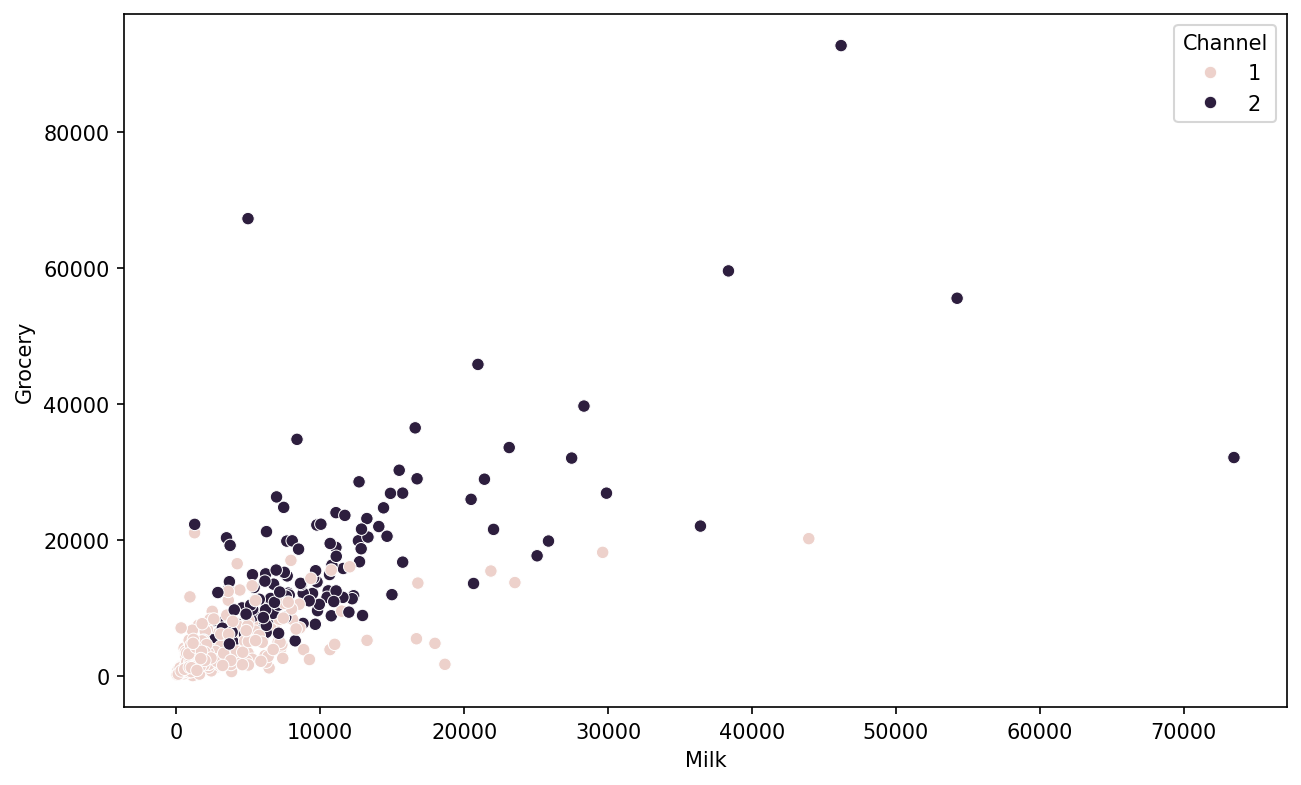

In [5]:
plt.figure(figsize=(10, 6), dpi=150)
sns.scatterplot(
    data=df,
    x='Milk',
    y='Grocery',
    hue='Channel'
)

<Axes: xlabel='Milk', ylabel='Count'>

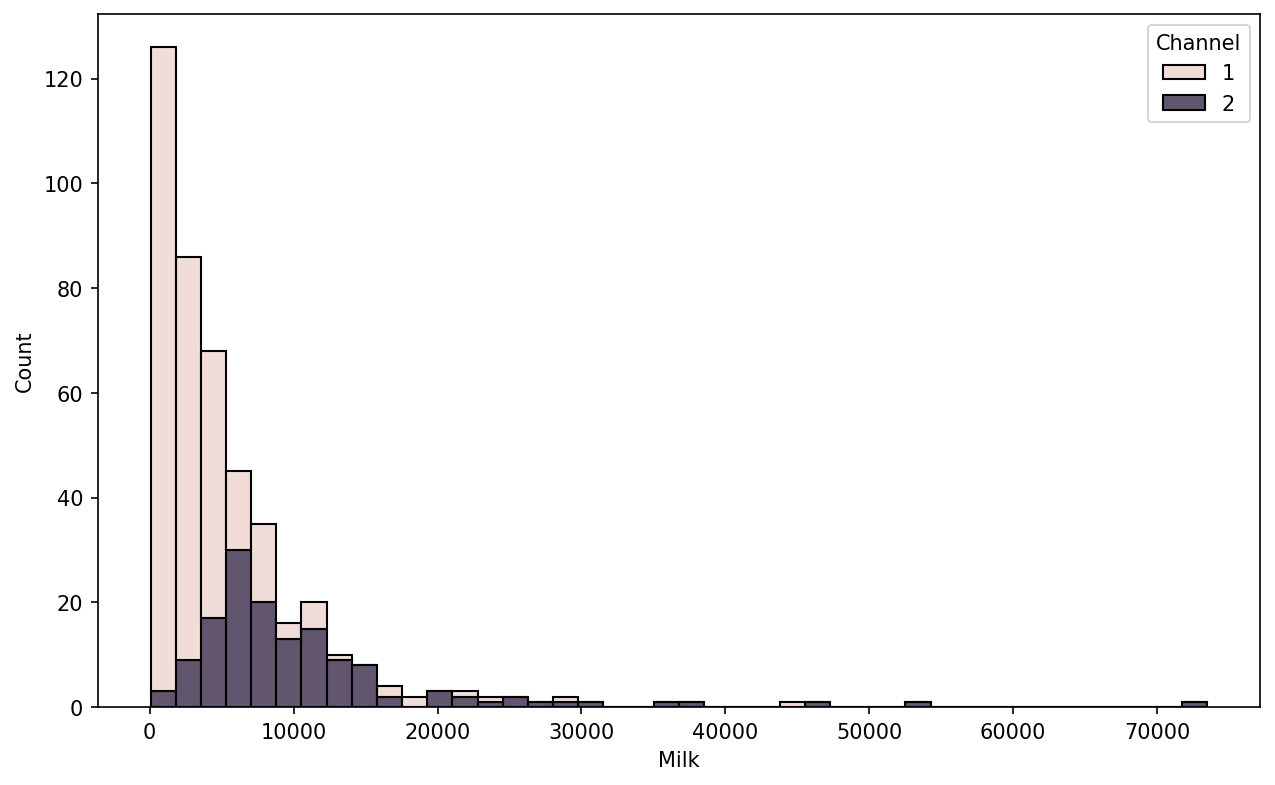

In [11]:
plt.figure(figsize=(10, 6), dpi=150)
sns.histplot(
    data=df,
    x='Milk',
    hue='Channel',
    multiple='stack'
)

<Figure size 1200x600 with 0 Axes>

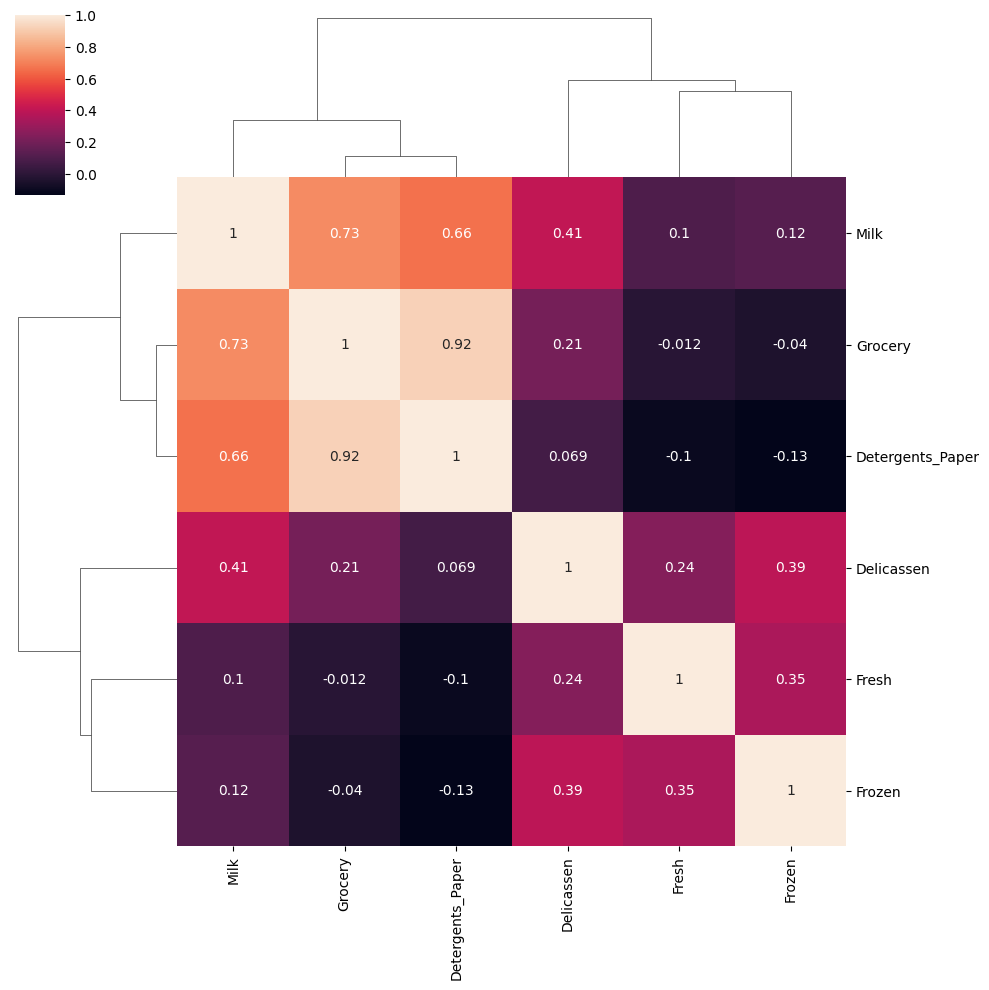

In [18]:
plt.figure(figsize=(8, 4), dpi=150)
sns.clustermap(
    data=df.drop(['Region','Channel'],axis=1).corr(),
    annot=True
)

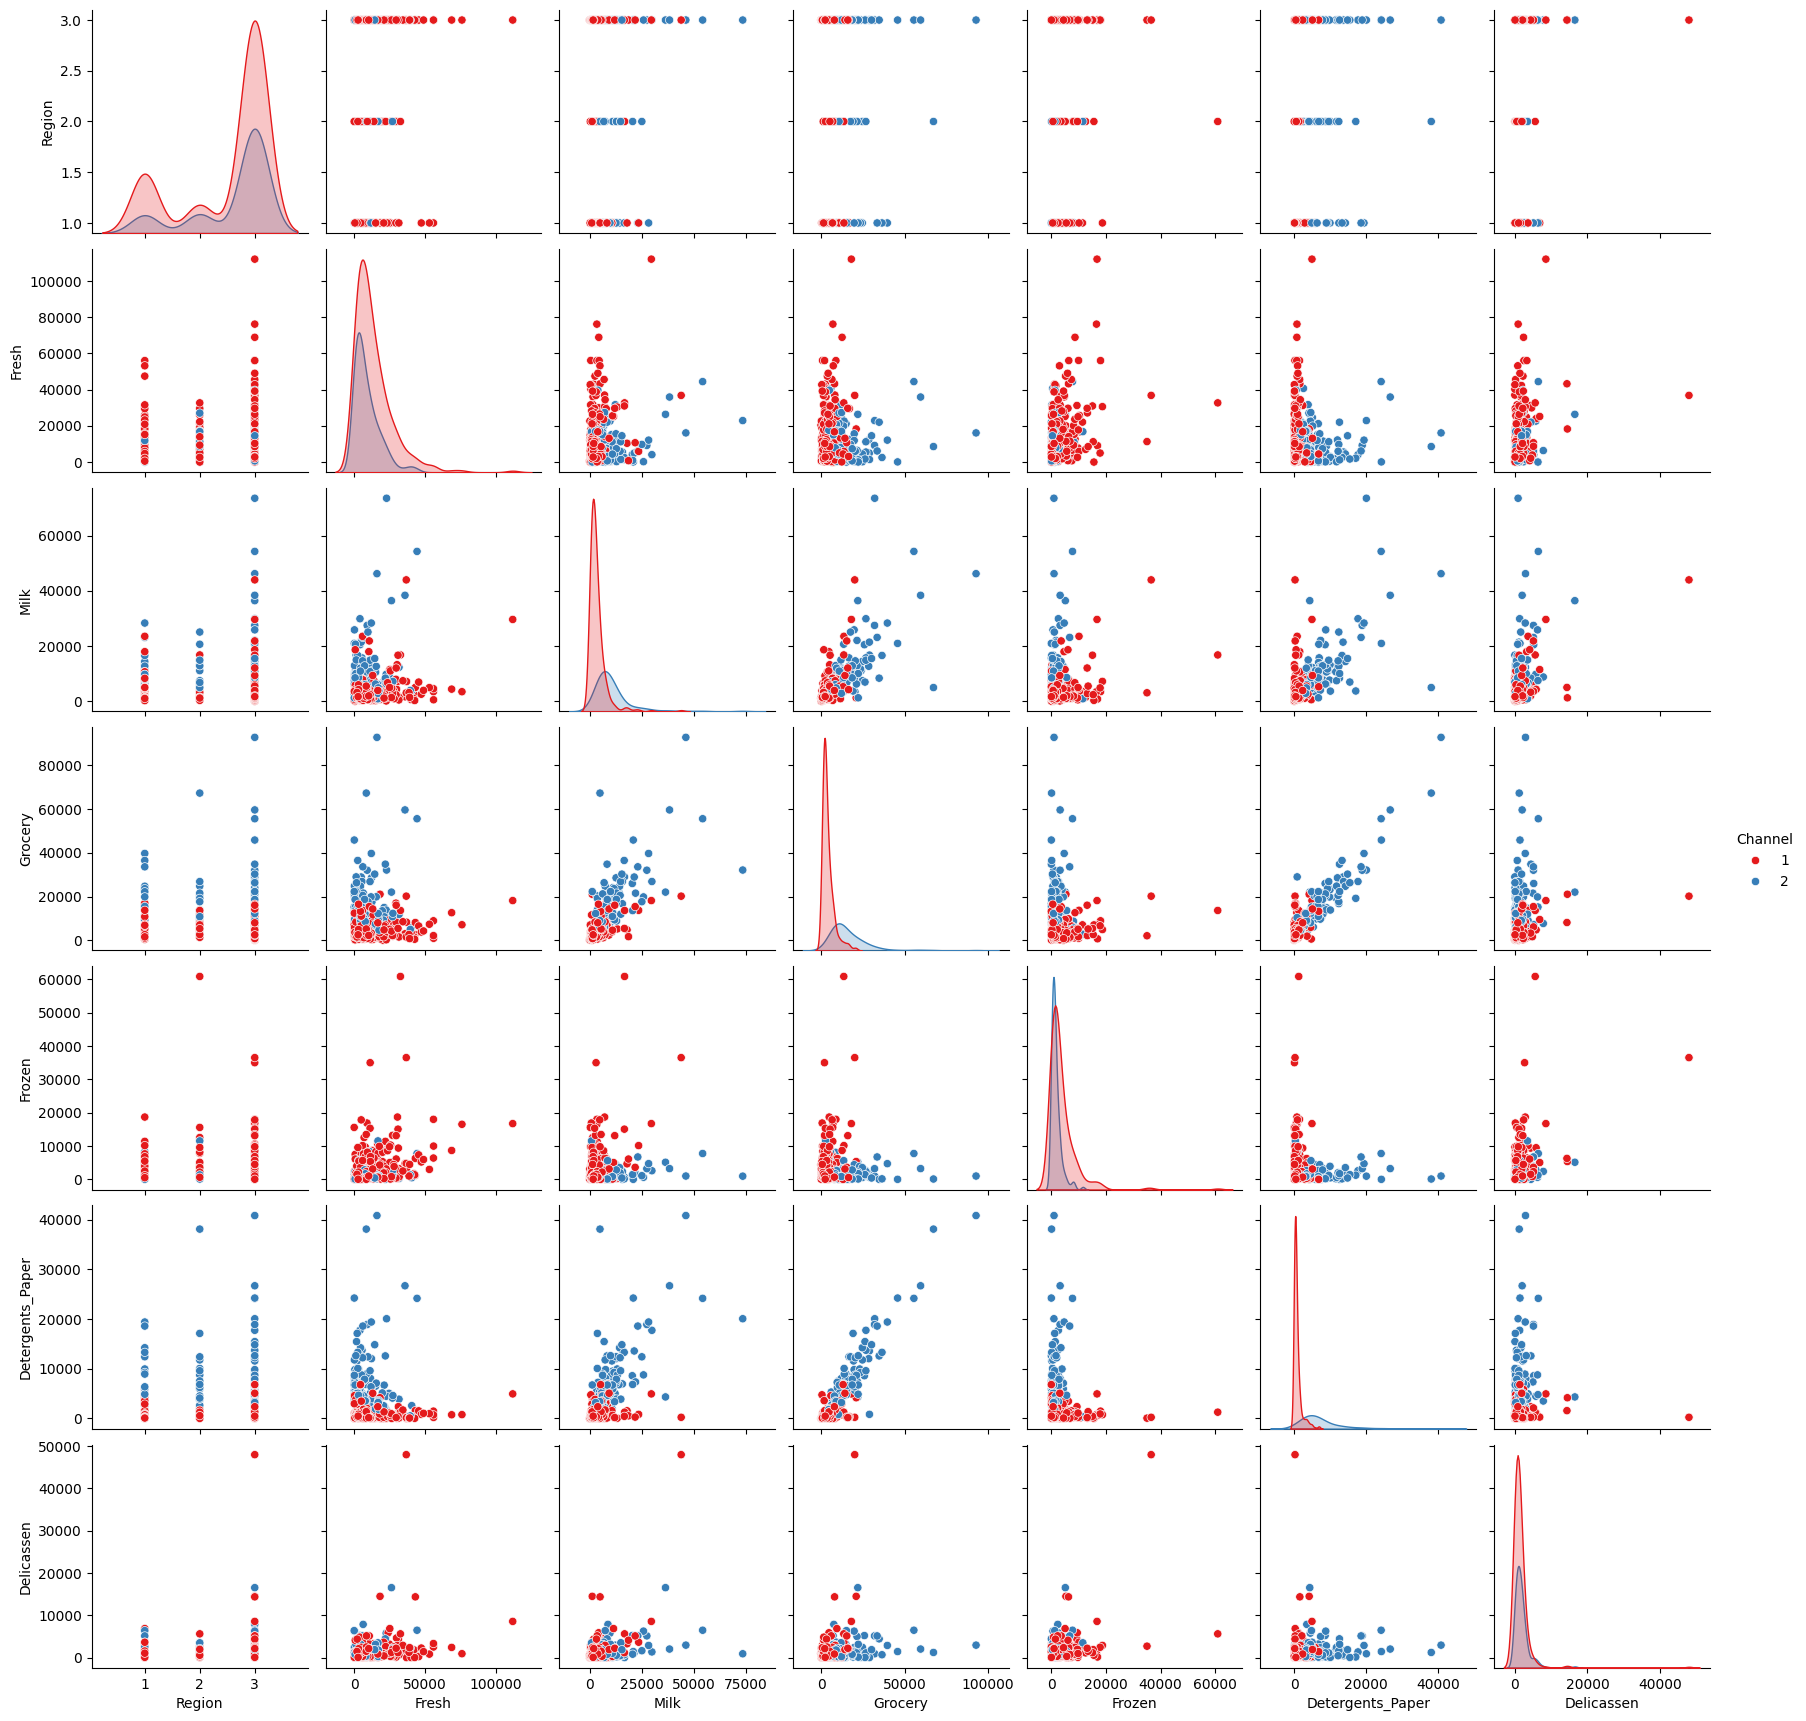

In [20]:
sns.pairplot(
    data=df,
    hue='Channel',
    palette='Set1'
)

In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [23]:
scaled_X = scaler.fit_transform(df)
scaled_X

array([[ 1.44865163,  0.59066829,  0.05293319, ..., -0.58936716,
        -0.04356873, -0.06633906],
       [ 1.44865163,  0.59066829, -0.39130197, ..., -0.27013618,
         0.08640684,  0.08915105],
       [ 1.44865163,  0.59066829, -0.44702926, ..., -0.13753572,
         0.13323164,  2.24329255],
       ...,
       [ 1.44865163,  0.59066829,  0.20032554, ..., -0.54337975,
         2.51121768,  0.12145607],
       [-0.69029709,  0.59066829, -0.13538389, ..., -0.41944059,
        -0.56977032,  0.21304614],
       [-0.69029709,  0.59066829, -0.72930698, ..., -0.62009417,
        -0.50488752, -0.52286938]], shape=(440, 8))

In [24]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN()

In [27]:
outlier_percent = []

for eps in np.linspace(0.001,3,50):
    dbscan = DBSCAN(eps=eps, min_samples=2*scaled_X.shape[1])
    dbscan.fit(scaled_X)

    # Percentage points classified as outliers
    percent_outleers = (100 * np.sum(dbscan.labels_ == -1) / len(dbscan.labels_))
    outlier_percent.append(percent_outleers)

Text(0.5, 0, 'Epsilon Value')

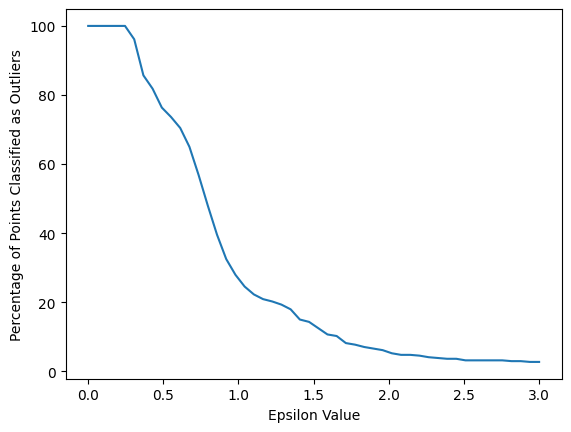

In [29]:
sns.lineplot(x=np.linspace(0.001,3,50),y=outlier_percent)
plt.ylabel("Percentage of Points Classified as Outliers")
plt.xlabel("Epsilon Value")

In [30]:
dbscan = DBSCAN(eps=2)
dbscan.fit(scaled_X)

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",2
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",5
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


<Axes: xlabel='Milk', ylabel='Grocery'>

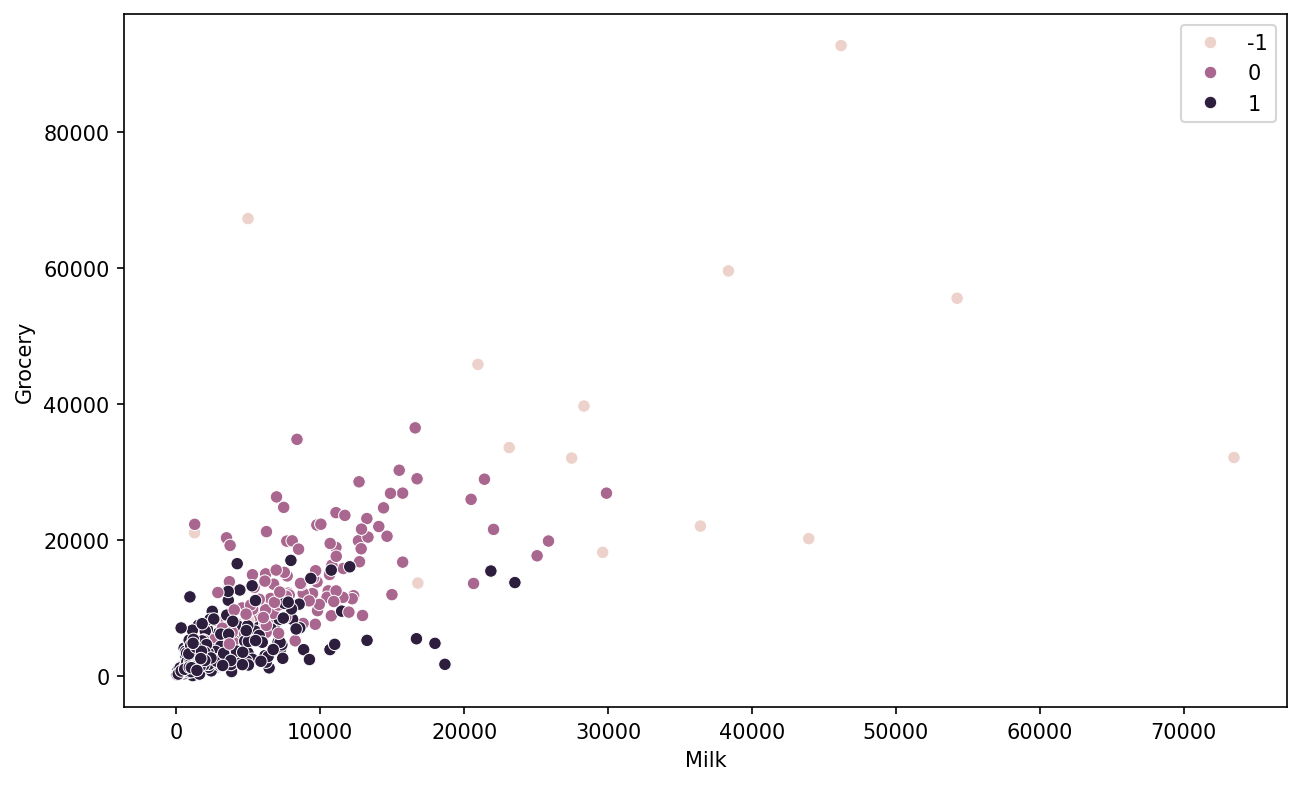

In [ ]:
plt.figure(figsize=(10, 6), dpi=150)
sns.scatterplot(
    data=df,
    x='Milk',
    y='Grocery',
    hue=dbscan.labels_
)

<Axes: xlabel='Detergents_Paper', ylabel='Milk'>

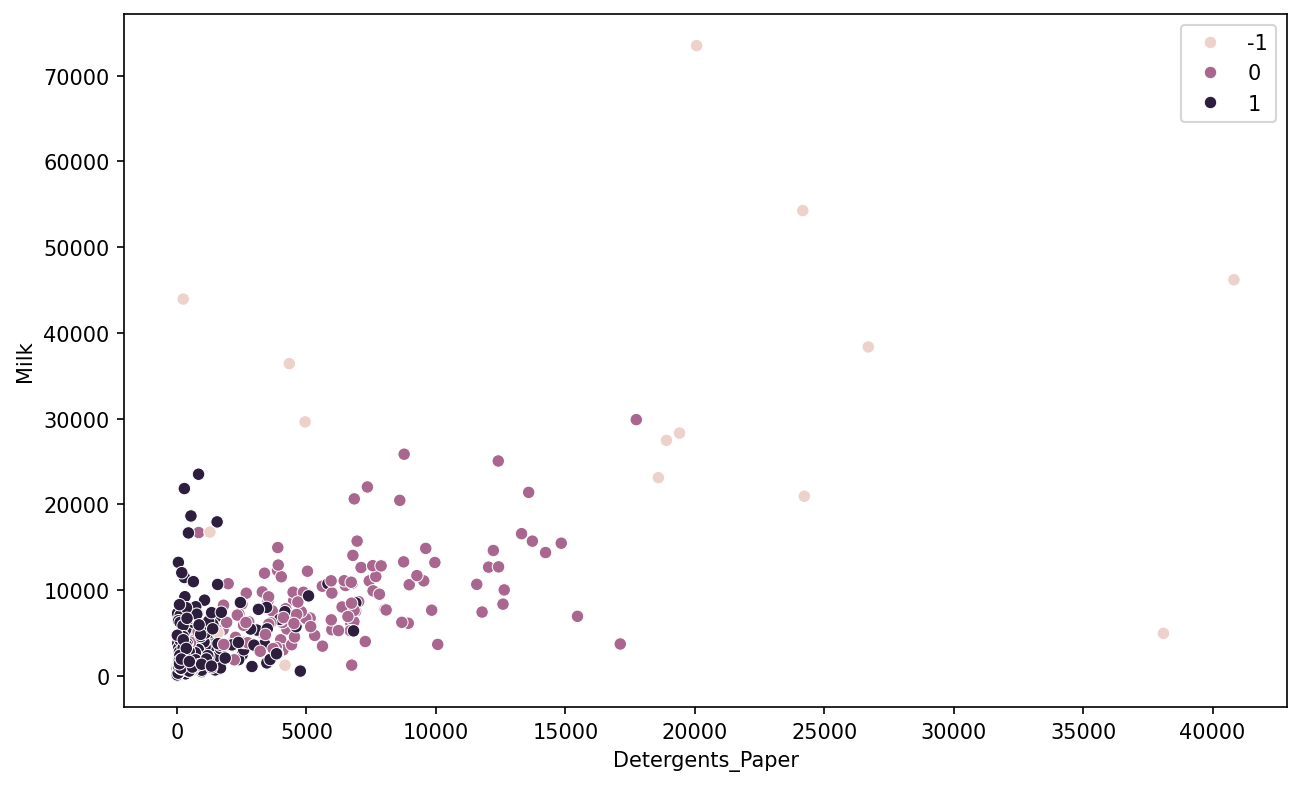

In [32]:
plt.figure(figsize=(10, 6), dpi=150)
sns.scatterplot(
    data=df,
    x='Detergents_Paper',
    y='Milk',
    hue=dbscan.labels_
)

In [33]:
df['Labels'] = dbscan.labels_

In [34]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Labels
0,2,3,12669,9656,7561,214,2674,1338,0
1,2,3,7057,9810,9568,1762,3293,1776,0
2,2,3,6353,8808,7684,2405,3516,7844,0
3,1,3,13265,1196,4221,6404,507,1788,1
4,2,3,22615,5410,7198,3915,1777,5185,0


In [35]:
estatistics = df.drop(['Region', 'Channel'], axis=1).groupby('Labels').mean()

In [36]:
estatistics

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Labels,,,,,,
-1,30161.529412,26872.411765,33575.823529,12380.235294,14612.294118,8185.411765
0,8200.681818,8849.446970,13919.113636,1527.174242,6037.280303,1548.310606
1,12662.869416,3180.065292,3747.250859,3228.862543,764.697595,1125.134021


In [37]:
from sklearn.preprocessing import MinMaxScaler
minmax_scaler = MinMaxScaler()

In [40]:
estatistics_normalized = pd.DataFrame(
    minmax_scaler.fit_transform(estatistics),
    columns=estatistics.columns, 
    index=estatistics.index
)

In [41]:
estatistics_normalized

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Labels,,,,,,
-1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
0,0.000000,0.239292,0.341011,0.000000,0.380758,0.059938
1,0.203188,0.000000,0.000000,0.156793,0.000000,0.000000


<Axes: ylabel='Labels'>

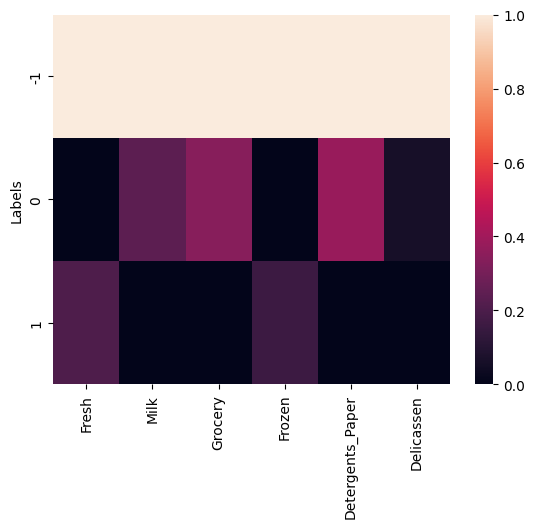

In [43]:
sns.heatmap(
    data=estatistics_normalized,
    annot=False
)

<Axes: ylabel='Labels'>

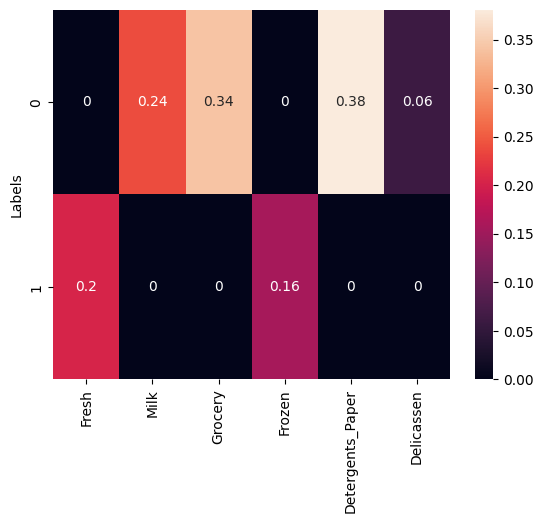

In [45]:
sns.heatmap(
    data=estatistics_normalized.drop(-1, axis=0),
    annot=True
)